In [18]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import palettable.wesanderson as wes

from distributions import *
import seaborn as sns

from factor_analyzer import FactorAnalyzer
import joblib

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
subgroups = pd.read_csv('./../../data/02_processed/TRACKING/subgroups.csv' , index_col=0)['PATNO']

with open('./../../data/02_processed/TRACKING/P1ON_MDSUPDRS.pkl' , 'rb') as file : 
    p1 = pickle.load(file)

with open('./../../data/02_processed/TRACKING/P2ON_MDSUPDRS.pkl' , 'rb') as file : 
    p2 = pickle.load(file)

with open('./../../data/02_processed/TRACKING/P3ON_MDSUPDRS.pkl' , 'rb') as file : 
    p3_on = pickle.load(file)

with open('./../../data/02_processed/TRACKING/P3OFF_MDSUPDRS.pkl' , 'rb') as file : 
    p3_off = pickle.load(file)

In [20]:
p1 = p1[p1['PATNO'].isin(subgroups)]
p2 = p2[p2['PATNO'].isin(subgroups)]
p3_on = p3_on[p3_on['PATNO'].isin(subgroups)]
p3_off = p3_off[p3_off['PATNO'].isin(subgroups)]

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Eigenvalues: [9.84058913 3.61319128 2.75891216 2.08477415 1.53906897 1.23178388
 1.20103239 1.02546712 0.83477593 0.81720922 0.76999349 0.67594468
 0.6293002  0.57425501 0.55147491 0.50818651 0.48403139 0.45156541
 0.42111049 0.39941547 0.39400766 0.37870861 0.34485597 0.33292603
 0.32393791 0.28672247 0.26230323 0.24788738 0.23033934 0.21090405
 0.18103724 0.15389474 0.12853682 0.11185677]


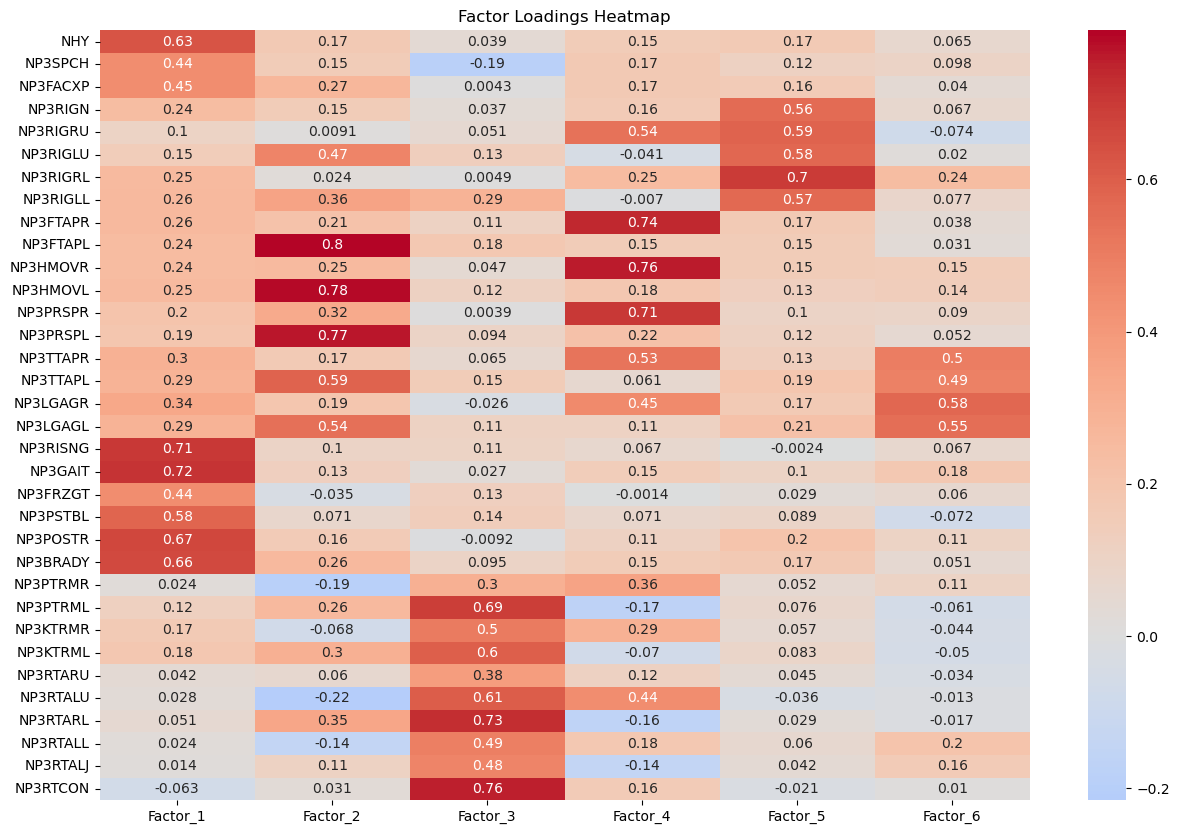

In [31]:
# Initialize the FactorAnalyzer object
fa = FactorAnalyzer(n_factors=6, rotation="varimax")

p3 = p3_off.copy()

# Fit the model
fa.fit(p3.iloc[: , 2:-1])
p3_cols = p3.iloc[: , 2:-1].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(p3.iloc[: , 2:-1].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('MDS_UPDRS_P3_')

factor_scores_df['PATNO'] = p3.dropna(subset=p3_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = p3.dropna(subset=p3_cols).reset_index(drop=True)['EVENT_ID']
p3_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=p3_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(15, 10))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')

plt.savefig('./../Results/TRCK_FA_P3.png' , bbox_inches='tight')
plt.show()

In [32]:
fa_labels = {'Factor_3' : 'TREMOR','Factor_1' : 'PIG','Factor_2' : 'TAPPING_L','Factor_4' : 'TAPPING_R','Factor_6' : 'NA','Factor_5' : 'RISING'}
joblib.dump({"fa": fa, 'labels':fa_labels}, "../../data/03_final/TRACKING_FA_model_P3OFF.joblib")

['../../data/03_final/TRACKING_FA_model_P3OFF.joblib']

Eigenvalues: [8.94601541 3.27311307 2.81301549 2.197335   1.76314036 1.21443307
 1.19716377 0.95408603 0.87212393 0.84646785 0.76694977 0.7140217
 0.65230351 0.60041317 0.56558643 0.52026524 0.51392759 0.49889272
 0.49160596 0.45859912 0.42025616 0.40182995 0.38595445 0.37177581
 0.36442605 0.33923595 0.33156113 0.30752292 0.3014521  0.24826865
 0.22389986 0.16818785 0.13922827 0.13694167]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


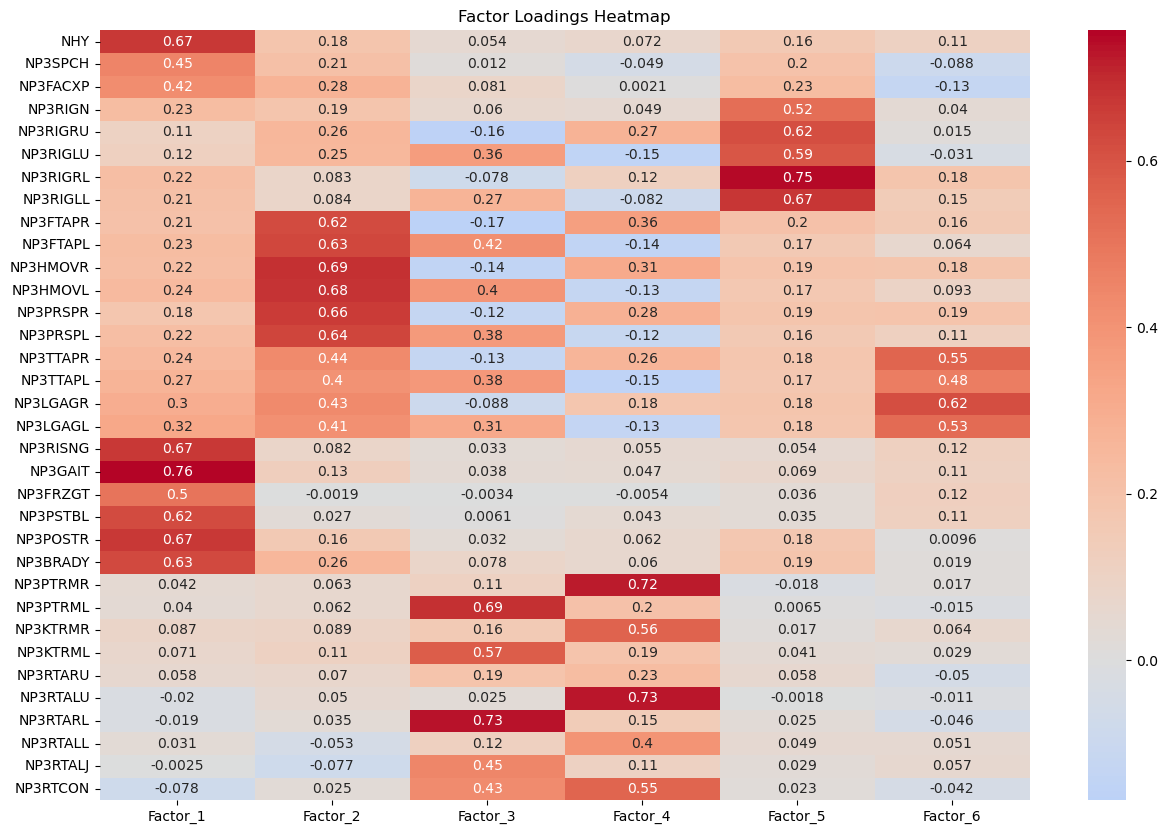

In [23]:
# Initialize the FactorAnalyzer object
fa = FactorAnalyzer(n_factors=6, rotation="varimax")

p3 = p3_on.copy()

# Fit the model
fa.fit(p3.iloc[: , 2:-1])
p3_cols = p3.iloc[: , 2:-1].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(p3.iloc[: , 2:-1].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('MDS_UPDRS_P3_')

factor_scores_df['PATNO'] = p3.dropna(subset=p3_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = p3.dropna(subset=p3_cols).reset_index(drop=True)['EVENT_ID']
p3_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=p3_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(15, 10))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()

In [7]:
fa_labels = {'Factor_1' : 'TAPPING','Factor_2' : 'PIG','Factor_3' : 'TREMOR_L','Factor_5' : 'TREMOR_R','Factor_6' : 'NA','Factor_4' : 'RISING'}
joblib.dump({"fa": fa, 'labels':fa_labels}, "../../data/03_final/TRACKING_FA_model_P3ON.joblib")

['../../data/03_final/TRACKING_FA_model_P3ON.joblib']

Eigenvalues: [5.47531351 1.0853921  1.03530988 0.81994206 0.76206379 0.68105948
 0.59342324 0.55007095 0.48898643 0.43294705 0.42627402 0.35543391
 0.29378357]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


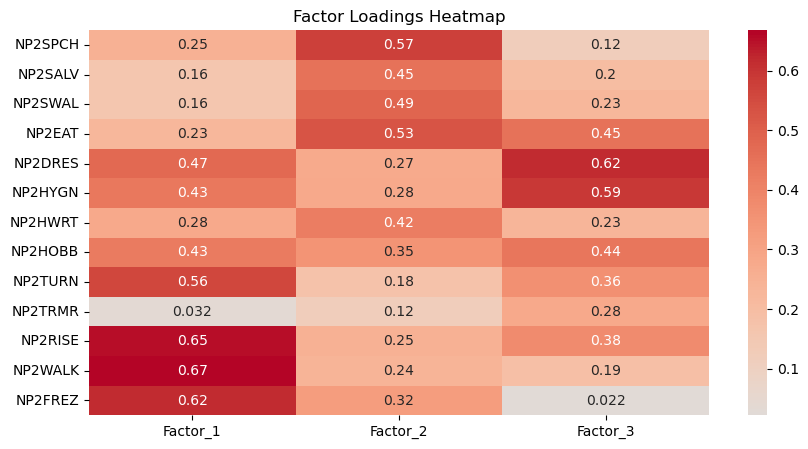

In [27]:
from factor_analyzer import FactorAnalyzer
import joblib

# Initialize the FactorAnalyzer object
fa = FactorAnalyzer(n_factors=3, rotation="varimax")

# Fit the model
fa.fit(p2.iloc[: , 2:-1])
p2_cols = p2.iloc[: , 2:-1].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(p2.iloc[: , 2:-1].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('MDS_UPDRS_P2_')

factor_scores_df['PATNO'] = p2.dropna(subset=p2_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = p2.dropna(subset=p2_cols).reset_index(drop=True)['EVENT_ID']
p2_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=p2_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(10, 5))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')

plt.savefig('./../Results/TRCK_FA_P2.png' , bbox_inches='tight')
plt.show()

In [28]:
fa_labels = {'Factor_2' : 'SPEECH','Factor_1' : 'RISE+WALK','Factor_3' : 'EAT'}
joblib.dump({"fa": fa, 'labels':fa_labels}, "../../data/03_final/TRACKING_FA_model_P2.joblib")

['../../data/03_final/TRACKING_FA_model_P2.joblib']

Eigenvalues: [3.44658136 1.45866665 1.05613204 0.97206479 0.86188713 0.85421228
 0.75483335 0.68254248 0.67383628 0.64962437 0.5798969  0.54718048
 0.4625419 ]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


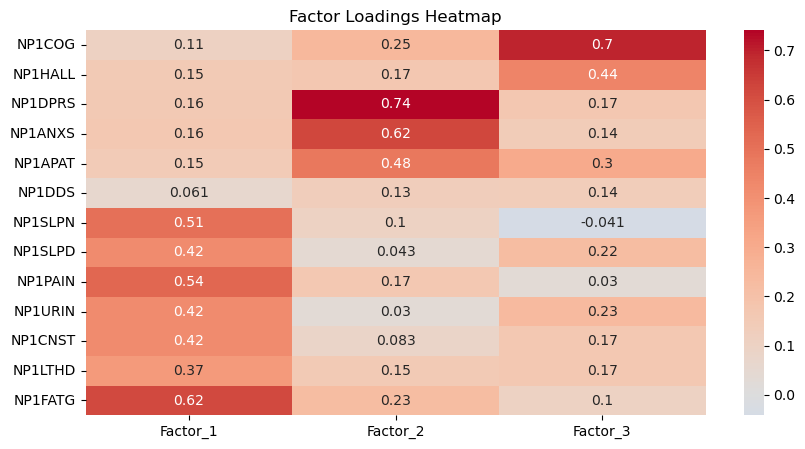

In [29]:
from factor_analyzer import FactorAnalyzer
import joblib

# Initialize the FactorAnalyzer object
fa = FactorAnalyzer(n_factors=3, rotation="varimax")

# Fit the model
fa.fit(p1.iloc[: , 2:-1])
p1_cols = p1.iloc[: , 2:-1].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(p1.iloc[: , 2:-1].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('MDS_UPDRS_P1_')

factor_scores_df['PATNO'] = p1.dropna(subset=p1_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = p1.dropna(subset=p1_cols).reset_index(drop=True)['EVENT_ID']
p1_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=p1_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(10, 5))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')

plt.savefig('./../Results/TRCK_FA_P1.png' , bbox_inches='tight')
plt.show()

In [30]:
fa_labels = {'Factor_1' : 'FATIGUE','Factor_2' : 'DEPRESSION+ANXIETY','Factor_3' : 'COGNITION'}
joblib.dump({"fa": fa,'labels':fa_labels}, "../../data/03_final/TRACKING_FA_model_P1.joblib")

['../../data/03_final/TRACKING_FA_model_P1.joblib']